INFO:pypsa.io:Imported network elec_s_79_ec_lcopt_Co2L-3h.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


Index(['BN3 0', 'ID12 0', 'ID12 1', 'ID13 0', 'ID13 1', 'ID14 0', 'ID14 1',
       'ID15 0', 'ID18 0', 'ID18 1',
       ...
       'SG6 0 battery', 'TH0 0 battery', 'TH0 1 battery', 'TH0 2 battery',
       'TH33 0 battery', 'TH34 0 battery', 'VN11 0 battery', 'VN11 1 battery',
       'VN11 2 battery', 'VN17 0 battery'],
      dtype='object', name='Bus', length=237)
Index(['BN3 0', 'ID12 0', 'ID12 1', 'ID13 0', 'ID13 1', 'ID14 0', 'ID14 1',
       'ID18 0', 'ID18 1', 'ID19 0', 'ID19 1', 'ID20 0', 'ID20 1', 'ID21 0',
       'ID21 1', 'ID22 0', 'ID22 1', 'ID23 0', 'ID23 1', 'ID24 0', 'ID24 1',
       'ID25 0', 'ID25 1', 'ID26 0', 'ID26 1', 'ID27 0', 'ID27 1', 'ID28 0',
       'ID28 1', 'ID29 0', 'ID29 1', 'ID30 0', 'ID30 1', 'ID31 0', 'ID31 1',
       'KH0 0', 'KH0 1', 'KH16 0', 'KH16 1', 'LA0 0', 'LA11 0', 'LA16 0',
       'LA17 0', 'MM0 0', 'MM0 1', 'MM0 10', 'MM0 11', 'MM0 12', 'MM0 2',
       'MM0 3', 'MM0 4', 'MM0 5', 'MM0 6', 'MM0 7', 'MM0 8', 'MM0 9', 'MY1 0',
       'MY2 0', 'MY2 

/scratch/htc/ffakhira/micromamba_root/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


(<matplotlib.collections.PatchCollection at 0x7f789125e110>,
 <matplotlib.collections.LineCollection at 0x7f7891019910>)

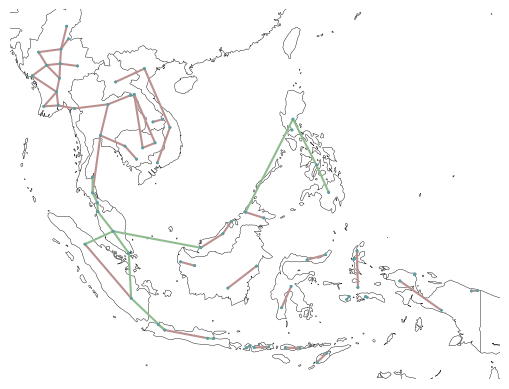

In [4]:
import pypsa
#n = pypsa.Network("results/prenetworks/elec_s_30_ec_lcopt_Co2L0.05-EQ0.1c-72h_144h_2030_0.071_NZ_10export.nc")
n = pypsa.Network("networks/elec_s_79_ec_lcopt_Co2L-3h.nc")
print(n.buses.index)
print(n.loads.index)
print(n.loads.head())
    # if any bus coord is literally "bus0" or non-numeric, show it
bad_bus_xy = n.buses[["x","y"]].astype(str).apply(lambda s: s.str.contains(r"\bbus0\b", case=False, na=False))
if bad_bus_xy.any().any():
    print("buses with 'bus0' in x/y:")
    print(n.buses.loc[bad_bus_xy.any(axis=1), ["x","y"]].head(20))

    # if any link has bus0 value == "bus0"
bad_links = n.links["bus0"].astype(str).eq("bus0") | n.links["bus1"].astype(str).eq("bus0")
if bad_links.any():
    print("links with literal bus0/bus1 == 'bus0':")
    print(n.links.loc[bad_links, ["bus0","bus1"]].head(20))
n.plot()

In [5]:
import pypsa
import pandas as pd
import numpy as np

path = "results/prenetworks-brownfield/elec_s_79_lcopt_Co2L-3h_3h_2030_0.05_ASEAN_0export.nc"
n = pypsa.Network(path)

def _nan_report_static(df, cols, name, n_show=10):
    cols = [c for c in cols if c in df.columns]
    if not cols:
        return {}
    out = {}
    for c in cols:
        m = df[c].isna()
        if m.any():
            out[c] = int(m.sum())
            print(f"\n[{name}] NaNs in {c}: {m.sum()} / {len(df)}")
            print(df.loc[m, cols + [x for x in ["bus","bus0","bus1","carrier","p_nom_extendable","p_set"] if x in df.columns]].head(n_show))
    return out

print("=== network loaded ===")
print("buses:", len(n.buses), "generators:", len(n.generators), "loads:", len(n.loads),
      "links:", len(n.links), "lines:", len(n.lines), "stores:", len(n.stores),
      "storage_units:", len(n.storage_units))

# 1) check the usual suspects for NaNs that break solve / create huge rhs
_nan_report_static(n.loads, ["p_set", "q_set", "sign"], "loads")
_nan_report_static(n.generators, ["p_nom", "p_nom_min", "p_nom_max", "marginal_cost", "capital_cost", "efficiency"], "generators")
_nan_report_static(n.links, ["p_nom", "p_nom_min", "p_nom_max", "marginal_cost", "capital_cost", "efficiency"], "links")
_nan_report_static(n.lines, ["s_nom", "s_nom_min", "s_nom_max", "r", "x"], "lines")
_nan_report_static(n.stores, ["e_nom", "e_nom_min", "e_nom_max", "marginal_cost", "capital_cost"], "stores")
_nan_report_static(n.storage_units, ["p_nom", "p_nom_min", "p_nom_max", "max_hours", "marginal_cost", "capital_cost", "efficiency_store", "efficiency_dispatch"], "storage_units")

# 2) time series NaNs (these are even more important than static)
def _nan_report_timeseries(ts, name, n_show=5):
    if ts is None or len(ts.columns) == 0:
        return
    m = ts.isna()
    if m.values.any():
        counts = m.sum().sort_values(ascending=False)
        bad = counts[counts > 0]
        print(f"\n[{name}] time series NaNs: {int(m.values.sum())} total")
        print(bad.head(20))
        # show first few timestamps for worst offenders
        worst = bad.head(n_show).index.tolist()
        for col in worst:
            idx = ts.index[m[col]].tolist()[:10]
            print(f"  - {col}: first NaN snapshots -> {idx}")

_nan_report_timeseries(getattr(n.loads_t, "p_set", None), "loads_t.p_set")
_nan_report_timeseries(getattr(n.generators_t, "p_max_pu", None), "generators_t.p_max_pu")
_nan_report_timeseries(getattr(n.generators_t, "p_min_pu", None), "generators_t.p_min_pu")
_nan_report_timeseries(getattr(n.links_t, "p_max_pu", None), "links_t.p_max_pu")

# 3) quick sanity: any buses referenced but missing (often tied to NaNs / dropped components)
def _missing_buses(component, bus_cols):
    df = getattr(n, component)
    miss = {}
    for bc in bus_cols:
        if bc in df.columns:
            bad = df[~df[bc].isin(n.buses.index)]
            if len(bad):
                miss[bc] = bad.index[:10].tolist()
                print(f"\n[{component}] missing buses in {bc}: {len(bad)} (showing 10)")
                print(bad[[bc]].head(10))
    return miss

_missing_buses("generators", ["bus"])
_missing_buses("loads", ["bus"])
_missing_buses("links", ["bus0","bus1","bus2","bus3","bus4"])
_missing_buses("lines", ["bus0","bus1"])
_missing_buses("storage_units", ["bus"])
_missing_buses("stores", ["bus"])


Index(['MY4 0 solar rooftop-2030'], dtype='object', name='name')
Index(['BN3 0 urban central solid biomass CHP CC-2030',
       'ID12 0 urban central solid biomass CHP CC-2030',
       'ID12 1 urban central solid biomass CHP CC-2030',
       'ID13 0 urban central solid biomass CHP CC-2030',
       'ID13 1 urban central solid biomass CHP CC-2030',
       'ID14 0 urban central solid biomass CHP CC-2030',
       'ID14 1 urban central solid biomass CHP CC-2030',
       'ID18 0 urban central solid biomass CHP CC-2030',
       'ID18 1 urban central solid biomass CHP CC-2030',
       'ID19 0 urban central solid biomass CHP CC-2030',
       'ID19 1 urban central solid biomass CHP CC-2030',
       'ID20 0 urban central solid biomass CHP CC-2030',
       'ID20 1 urban central solid biomass CHP CC-2030',
       'ID21 0 urban central solid biomass CHP CC-2030',
       'ID21 1 urban central solid biomass CHP CC-2030',
       'ID22 0 urban central solid biomass CHP CC-2030',
       'ID22 1 urban cen

=== network loaded ===
buses: 1734 generators: 1117 loads: 2185 links: 3822 lines: 49 stores: 1053 storage_units: 38

[loads] NaNs in p_set: 3 / 2185
                              p_set  q_set  sign         bus  \
Load                                                           
TH34 0 H2 for shipping          NaN    0.0  -1.0   TH34 0 H2   
TH34 0 shipping oil             NaN    0.0  -1.0  TH34 0 oil   
TH34 0 kerosene for aviation    NaN    0.0  -1.0  TH34 0 oil   

                                            carrier  p_set  
Load                                                        
TH34 0 H2 for shipping              H2 for shipping    NaN  
TH34 0 shipping oil                    shipping oil    NaN  
TH34 0 kerosene for aviation  kerosene for aviation    NaN  

[generators] missing buses in bus: 1 (showing 10)
                                        bus
Generator                                  
MY4 0 solar rooftop-2030  MY4 0 low voltage

[links] missing buses in bus0: 75 (showi

{}

In [6]:
import pypsa
import numpy as np

inpath  = "results/prenetworks-brownfield/elec_s_79_lcopt_Co2L-3h_3h_2030_0.05_ASEAN_0export.nc"
outpath = "results/prenetworks-brownfield/elec_s_79_lcopt_Co2L-3h_3h_2030_0.05_ASEAN_0export.CLEAN.nc"

n = pypsa.Network(inpath)

# 1) fix NaN loads.p_set (and time series if present)
if "p_set" in n.loads.columns:
    na = n.loads.p_set.isna()
    if na.any():
        print("fixing NaN loads.p_set:", na.sum())
        print(n.loads.loc[na, ["bus","carrier","p_set"]])
        n.loads.loc[na, "p_set"] = 0.0

if hasattr(n, "loads_t") and hasattr(n.loads_t, "p_set"):
    ts = n.loads_t.p_set
    if ts.isna().values.any():
        print("fixing NaN loads_t.p_set:", int(ts.isna().sum().sum()))
        n.loads_t.p_set = ts.fillna(0.0)

# 2) replace empty-string buses in links with NaN (optional terminals)
for bc in ["bus2","bus3","bus4"]:
    if bc in n.links.columns:
        n.links[bc] = n.links[bc].replace("", np.nan)

# 3) drop links with missing mandatory buses (bus0/bus1 must exist)
bad0 = n.links.bus0.isna() | (n.links.bus0.astype(str).str.strip() == "") | (~n.links.bus0.isin(n.buses.index))
bad1 = n.links.bus1.isna() | (n.links.bus1.astype(str).str.strip() == "") | (~n.links.bus1.isin(n.buses.index))
bad_links = n.links.index[bad0 | bad1]
print("dropping links with invalid bus0/bus1:", len(bad_links))
if len(bad_links):
    n.mremove("Link", bad_links)

# 4) drop generators whose bus doesn't exist
bad_g = ~n.generators.bus.isin(n.buses.index)
bad_gens = n.generators.index[bad_g]
print("dropping generators with invalid bus:", len(bad_gens))
if len(bad_gens):
    print(n.generators.loc[bad_gens, ["bus","carrier"]].head(20))
    n.mremove("Generator", bad_gens)

n.export_to_netcdf(outpath)
print("wrote:", outpath)


Index(['MY4 0 solar rooftop-2030'], dtype='object', name='name')
Index(['BN3 0 urban central solid biomass CHP CC-2030',
       'ID12 0 urban central solid biomass CHP CC-2030',
       'ID12 1 urban central solid biomass CHP CC-2030',
       'ID13 0 urban central solid biomass CHP CC-2030',
       'ID13 1 urban central solid biomass CHP CC-2030',
       'ID14 0 urban central solid biomass CHP CC-2030',
       'ID14 1 urban central solid biomass CHP CC-2030',
       'ID18 0 urban central solid biomass CHP CC-2030',
       'ID18 1 urban central solid biomass CHP CC-2030',
       'ID19 0 urban central solid biomass CHP CC-2030',
       'ID19 1 urban central solid biomass CHP CC-2030',
       'ID20 0 urban central solid biomass CHP CC-2030',
       'ID20 1 urban central solid biomass CHP CC-2030',
       'ID21 0 urban central solid biomass CHP CC-2030',
       'ID21 1 urban central solid biomass CHP CC-2030',
       'ID22 0 urban central solid biomass CHP CC-2030',
       'ID22 1 urban cen

fixing NaN loads.p_set: 3
                                     bus                carrier  p_set
Load                                                                  
TH34 0 H2 for shipping         TH34 0 H2        H2 for shipping    NaN
TH34 0 shipping oil           TH34 0 oil           shipping oil    NaN
TH34 0 kerosene for aviation  TH34 0 oil  kerosene for aviation    NaN
dropping links with invalid bus0/bus1: 75
dropping generators with invalid bus: 1
                                        bus        carrier
Generator                                                 
MY4 0 solar rooftop-2030  MY4 0 low voltage  solar rooftop


INFO:pypsa.io:Exported network 'elec_s_79_lcopt_Co2L-3h_3h_2030_0.05_ASEAN_0export.CLEAN.nc' contains: global_constraints, carriers, loads, links, lines, generators, stores, buses, storage_units


wrote: results/prenetworks-brownfield/elec_s_79_lcopt_Co2L-3h_3h_2030_0.05_ASEAN_0export.CLEAN.nc


In [2]:
import pandas as pd
df = pd.read_csv("resources/demand/heat/heat_demand_NZ_s_30_2030.csv", index_col=0)
print(df.columns)  # or df.index


Index(['residential water', 'residential water.1', 'residential water.2',
       'residential water.3', 'residential water.4', 'residential water.5',
       'residential water.6', 'residential water.7', 'residential water.8',
       'residential water.9',
       ...
       'services space.262', 'services space.263', 'services space.264',
       'services space.265', 'services space.266', 'services space.267',
       'services space.268', 'services space.269', 'services space.270',
       'services space.271'],
      dtype='object', length=1088)


C:\Users\ffill\AppData\Local\Temp\ipykernel_4116\2542002416.py:2: DtypeWarning:

Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,25

In [9]:
#n = pypsa.Network("results/prenetworks/elec_s_30_ec_lcopt_Co2L0.05-EQ0.1c-72h_144h_2030_0.071_NZ_10export.nc")
n = pypsa.Network("networks/elec_s_200_ec_lcopt_Co2L-3h.nc")
print(n.buses.index)

INFO:pypsa.io:Imported network elec_s_200_ec_lcopt_Co2L-3h.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


Index(['BN15 0', 'ID1 0', 'ID1 1', 'ID1 2', 'ID1 3', 'ID1 4', 'ID10 0',
       'ID10 1', 'ID10 2', 'ID10 3',
       ...
       'VN0 15 battery', 'VN0 16 battery', 'VN0 2 battery', 'VN0 3 battery',
       'VN0 4 battery', 'VN0 5 battery', 'VN0 6 battery', 'VN0 7 battery',
       'VN0 8 battery', 'VN0 9 battery'],
      dtype='object', name='Bus', length=600)


In [1]:
import pandas as pd
import numpy as np

def audit_osm_by_projectid(df: pd.DataFrame,
                          *,
                          cap_col: str = "Capacity",
                          fuel_col: str = "Fueltype",
                          project_col: str = "projectID",
                          coal_regex: str = r"(hard\s*coal|coal|lignite)",
                          n_show: int = 10):
    """
    Quick audit: how much of df looks OSM-derived based on projectID prefix 'OSM'.
    Works on ppl (PPM-format) or any df that has projectID/Fueltype/Capacity.
    """
    out = df.copy()

    # projectID -> OSM?
    if project_col in out.columns:
        proj = out[project_col].astype(str)
        is_osm = proj.str.startswith("OSM", na=False)
    else:
        is_osm = pd.Series(False, index=out.index)

    # capacity numeric
    if cap_col in out.columns:
        cap = pd.to_numeric(out[cap_col], errors="coerce").fillna(0.0)
    else:
        cap = pd.Series(0.0, index=out.index)

    # coal-ish fuel
    if fuel_col in out.columns:
        fuel = out[fuel_col].astype(str)
        is_coal = fuel.str.contains(coal_regex, case=False, regex=True, na=False)
    else:
        is_coal = pd.Series(False, index=out.index)

    def _sum(mask):
        return float(cap[mask].sum())

    print("=== audit OSM by projectID ===")
    print("rows total:", len(out))
    print("OSM rows:", int(is_osm.sum()), "| MW:", _sum(is_osm))
    print("non-OSM rows:", int((~is_osm).sum()), "| MW:", _sum(~is_osm))
    print("---")
    print("coal-ish rows:", int(is_coal.sum()), "| MW:", _sum(is_coal))
    print("OSM coal-ish rows:", int((is_osm & is_coal).sum()), "| MW:", _sum(is_osm & is_coal))
    print("non-OSM coal-ish rows:", int(((~is_osm) & is_coal).sum()), "| MW:", _sum((~is_osm) & is_coal))

    # quick peek
    cols = [c for c in [project_col, "Name", "Country", fuel_col, cap_col, "Technology", "Set"] if c in out.columns]
    if is_osm.any():
        print("\nSample OSM rows:")
        display(out.loc[is_osm, cols].head(n_show))
    else:
        print("\nNo OSM rows detected (projectID not starting with 'OSM').")

    return {
        "osm_rows": int(is_osm.sum()),
        "osm_mw": _sum(is_osm),
        "osm_coal_rows": int((is_osm & is_coal).sum()),
        "osm_coal_mw": _sum(is_osm & is_coal),
    }

ppl=pd.read_csv("resources/powerplants.csv", index_col=0)
audit_osm_by_projectid(ppl)


=== audit OSM by projectID ===
rows total: 814
OSM rows: 0 | MW: 0.0
non-OSM rows: 814 | MW: 296821.419879447
---
coal-ish rows: 174 | MW: 109280.2014875155
OSM coal-ish rows: 0 | MW: 0.0
non-OSM coal-ish rows: 174 | MW: 109280.2014875155

No OSM rows detected (projectID not starting with 'OSM').


/tmp/ipykernel_1741732/3392967900.py:33: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  is_coal = fuel.str.contains(coal_regex, case=False, regex=True, na=False)


{'osm_rows': 0, 'osm_mw': 0.0, 'osm_coal_rows': 0, 'osm_coal_mw': 0.0}

In [ ]:
coal_mask = ppl["Fueltype"].str.contains("coal|lignite", case=False, na=False)

coal_age = 2030 - ppl["DateIn"]
retire = coal_mask & (coal_age > 40)

print("retiring coal by age:",
      retire.sum(),
      "MW:",
      ppl.loc[retire, "Capacity"].sum())

ppl = ppl.loc[~retire].copy()


retiring coal by age: 3 MW: 3146.087434882882


In [7]:
import pypsa

nc_file_name = "elec_s_79_ec_lcopt_Co2L-3h_3h_2030_0.05_ASEAN_0export.nc"
results_path = f"results/postnetworks/{nc_file_name}"
n = pypsa.Network(results_path)

coal_gen = n.generators[n.generators.carrier.str.contains("coal", case=False, na=False)]
coal_link = n.links[n.links.carrier.str.contains("coal", case=False, na=False)]

print("coal generators MW_e:",
      coal_gen.p_nom_opt.where(coal_gen.p_nom_extendable, coal_gen.p_nom).sum())

cap_in = coal_link.p_nom_opt.where(coal_link.p_nom_extendable, coal_link.p_nom)
eta = coal_link.efficiency.fillna(1.0)
print("coal links output MW_e:", (cap_in * eta).sum())

Index(['CO2 pipeline BN39-AC 0 <-> MY39-AC 0-2030',
       'CO2 pipeline ID15-AC 0 <-> MY39-AC 0-2030',
       'CO2 pipeline ID15-AC 0 <-> SG61-AC 0-2030',
       'CO2 pipeline KH0-AC 0 <-> TH0-AC 0-2030',
       'CO2 pipeline KH39-AC 0 <-> MY39-AC 0-2030',
       'CO2 pipeline KH45-AC 0 <-> LA45-AC 0-2030',
       'CO2 pipeline KH47-AC 0 <-> LA47-AC 0-2030',
       'CO2 pipeline LA0-AC 0 <-> TH0-AC 0-2030',
       'CO2 pipeline LA0-AC 0 <-> VN0-AC 0-2030',
       'CO2 pipeline LA45-AC 0 <-> TH45-AC 0-2030',
       'CO2 pipeline MM54-AC 0 <-> TH54-AC 0-2030',
       'CO2 pipeline MY39-AC 0 <-> PH2-AC 0-2030',
       'CO2 pipeline MY39-AC 0 <-> SG61-AC 0-2030',
       'CO2 pipeline MY44-AC 0 <-> MY44-DC 0-2030',
       'CO2 pipeline MY44-DC 0 <-> TH0-DC 0-2030',
       'CO2 pipeline PH2-AC 0 <-> PH4-AC 0-2030',
       'CO2 pipeline PH3-AC 0 <-> PH3-DC 0-2030',
       'CO2 pipeline PH3-AC 0 <-> PH52-AC 0-2030',
       'CO2 pipeline PH4-AC 0 <-> PH4-DC 0-2030',
       'CO2 pipeline TH0-AC

coal generators MW_e: 0.0
coal links output MW_e: 205988.08940461243


In [9]:
import pypsa
nc_file_name = "elec_s_79_ec_lcopt_Co2L-3h_3h_2030_0.05_ASEAN_0export.nc"
results_path =  f"results/postnetworks/{nc_file_name}"

#nc_file_name = "elec_s_79_ec_lcopt_Co2L-6h_6h_2030_0.05_ASEAN.nc"
#results_path = f"results/prenetworks/{nc_file_name}"

#nc_file_name = "elec_s_79_lcopt_Co2L-3h_3h_2035_0.05_ASEAN_0export.nc"
#results_path = f"results/prenetworks-brownfield/{nc_file_name}"

n = pypsa.Network(results_path)

coal_gen = n.generators[n.generators.carrier.str.contains("ccgt", case=False, na=False)]
coal_link = n.links[n.links.carrier.str.contains("ccgt", case=False, na=False)]

print("coal generators MW_e:",
      coal_gen.p_nom_opt.where(coal_gen.p_nom_extendable, coal_gen.p_nom).sum())

cap_in = coal_link.p_nom_opt.where(coal_link.p_nom_extendable, coal_link.p_nom)
eta = coal_link.efficiency.fillna(1.0)
print("coal links output MW_e:", (cap_in * eta).sum())

Index(['CO2 pipeline BN39-AC 0 <-> MY39-AC 0-2030',
       'CO2 pipeline ID15-AC 0 <-> MY39-AC 0-2030',
       'CO2 pipeline ID15-AC 0 <-> SG61-AC 0-2030',
       'CO2 pipeline KH0-AC 0 <-> TH0-AC 0-2030',
       'CO2 pipeline KH39-AC 0 <-> MY39-AC 0-2030',
       'CO2 pipeline KH45-AC 0 <-> LA45-AC 0-2030',
       'CO2 pipeline KH47-AC 0 <-> LA47-AC 0-2030',
       'CO2 pipeline LA0-AC 0 <-> TH0-AC 0-2030',
       'CO2 pipeline LA0-AC 0 <-> VN0-AC 0-2030',
       'CO2 pipeline LA45-AC 0 <-> TH45-AC 0-2030',
       'CO2 pipeline MM54-AC 0 <-> TH54-AC 0-2030',
       'CO2 pipeline MY39-AC 0 <-> PH2-AC 0-2030',
       'CO2 pipeline MY39-AC 0 <-> SG61-AC 0-2030',
       'CO2 pipeline MY44-AC 0 <-> MY44-DC 0-2030',
       'CO2 pipeline MY44-DC 0 <-> TH0-DC 0-2030',
       'CO2 pipeline PH2-AC 0 <-> PH4-AC 0-2030',
       'CO2 pipeline PH3-AC 0 <-> PH3-DC 0-2030',
       'CO2 pipeline PH3-AC 0 <-> PH52-AC 0-2030',
       'CO2 pipeline PH4-AC 0 <-> PH4-DC 0-2030',
       'CO2 pipeline TH0-AC

coal generators MW_e: 0.0
coal links output MW_e: 112431.64798590577


In [7]:
nc_file_name = "elec_s_79_ec_lcopt_Co2L-3h_3h_2040_0.05_ASEAN_0export.nc"
results_path = f"results/postnetworks/{nc_file_name}"

n = pypsa.Network(results_path)

ccgt = n.links[n.links.carrier.astype(str).str.lower().eq("ccgt")].copy()

# choose correct capacity column depending on extendability
cap = ccgt.p_nom_opt.where(ccgt.p_nom_extendable, ccgt.p_nom)

print("ccgt total MW_in:", float(cap.sum()))
print("\nccgt MW_in by build_year:")
print(cap.groupby(ccgt.build_year).sum().sort_index())
print("\ncounts by build_year:")
print(ccgt.build_year.value_counts().sort_index())

Index(['CO2 pipeline BN39-AC 0 <-> MY39-AC 0-2040',
       'CO2 pipeline ID15-AC 0 <-> MY39-AC 0-2040',
       'CO2 pipeline ID15-AC 0 <-> SG61-AC 0-2040',
       'CO2 pipeline KH0-AC 0 <-> TH0-AC 0-2040',
       'CO2 pipeline KH39-AC 0 <-> MY39-AC 0-2040',
       'CO2 pipeline KH45-AC 0 <-> LA45-AC 0-2040',
       'CO2 pipeline KH47-AC 0 <-> LA47-AC 0-2040',
       'CO2 pipeline LA0-AC 0 <-> TH0-AC 0-2040',
       'CO2 pipeline LA0-AC 0 <-> VN0-AC 0-2040',
       'CO2 pipeline LA45-AC 0 <-> TH45-AC 0-2040',
       'CO2 pipeline MM54-AC 0 <-> TH54-AC 0-2040',
       'CO2 pipeline MY39-AC 0 <-> PH2-AC 0-2040',
       'CO2 pipeline MY39-AC 0 <-> SG61-AC 0-2040',
       'CO2 pipeline MY44-AC 0 <-> MY44-DC 0-2040',
       'CO2 pipeline MY44-DC 0 <-> TH0-DC 0-2040',
       'CO2 pipeline PH2-AC 0 <-> PH4-AC 0-2040',
       'CO2 pipeline PH3-AC 0 <-> PH3-DC 0-2040',
       'CO2 pipeline PH3-AC 0 <-> PH52-AC 0-2040',
       'CO2 pipeline PH4-AC 0 <-> PH4-DC 0-2040',
       'CO2 pipeline TH0-AC

ccgt total MW_in: 540536.4787697527

ccgt MW_in by build_year:
build_year
2030    187561.510329
2035    176465.219342
2040    176509.749099
Name: p_nom_opt, dtype: float64

counts by build_year:
build_year
2030    55
2035    28
2040    77
Name: count, dtype: int64


In [1]:
import pypsa, pandas as pd

n = pypsa.Network("results/prenetworks-brownfield/elec_s_79_lcopt_Co2L-3h_3h_2040_0.05_ASEAN_0export.nc")

missing_gen_buses = n.generators.loc[~n.generators.bus.isin(n.buses.index), ["bus","carrier"]]
missing_link_b0   = n.links.loc[~n.links.bus0.isin(n.buses.index), ["bus0","bus1","carrier"]]
missing_link_b1   = n.links.loc[~n.links.bus1.isin(n.buses.index), ["bus0","bus1","carrier"]]

print("missing gen buses:", len(missing_gen_buses))
print(missing_gen_buses.head(20))
print("missing link bus0:", len(missing_link_b0))
print(missing_link_b0.head(20))
print("missing link bus1:", len(missing_link_b1))
print(missing_link_b1.head(20))


Index(['CO2 pipeline BN39-AC 0 <-> MY39-AC 0-2040',
       'CO2 pipeline ID15-AC 0 <-> MY39-AC 0-2040',
       'CO2 pipeline ID15-AC 0 <-> SG61-AC 0-2040',
       'CO2 pipeline KH0-AC 0 <-> TH0-AC 0-2040',
       'CO2 pipeline KH39-AC 0 <-> MY39-AC 0-2040',
       'CO2 pipeline KH45-AC 0 <-> LA45-AC 0-2040',
       'CO2 pipeline KH47-AC 0 <-> LA47-AC 0-2040',
       'CO2 pipeline LA0-AC 0 <-> TH0-AC 0-2040',
       'CO2 pipeline LA0-AC 0 <-> VN0-AC 0-2040',
       'CO2 pipeline LA45-AC 0 <-> TH45-AC 0-2040',
       'CO2 pipeline MM54-AC 0 <-> TH54-AC 0-2040',
       'CO2 pipeline MY39-AC 0 <-> PH2-AC 0-2040',
       'CO2 pipeline MY39-AC 0 <-> SG61-AC 0-2040',
       'CO2 pipeline MY44-AC 0 <-> MY44-DC 0-2040',
       'CO2 pipeline MY44-DC 0 <-> TH0-DC 0-2040',
       'CO2 pipeline PH2-AC 0 <-> PH4-AC 0-2040',
       'CO2 pipeline PH3-AC 0 <-> PH3-DC 0-2040',
       'CO2 pipeline PH3-AC 0 <-> PH52-AC 0-2040',
       'CO2 pipeline PH4-AC 0 <-> PH4-DC 0-2040',
       'CO2 pipeline TH0-AC

missing gen buses: 0
Empty DataFrame
Columns: [bus, carrier]
Index: []
missing link bus0: 97
                                                           bus0  \
Link                                                              
CO2 pipeline BN39-AC 0 <-> MY39-AC 0-2040  BN39-AC 0 co2 stored   
CO2 pipeline ID15-AC 0 <-> MY39-AC 0-2040  ID15-AC 0 co2 stored   
CO2 pipeline ID15-AC 0 <-> SG61-AC 0-2040  ID15-AC 0 co2 stored   
CO2 pipeline KH0-AC 0 <-> TH0-AC 0-2040     KH0-AC 0 co2 stored   
CO2 pipeline KH39-AC 0 <-> MY39-AC 0-2040  KH39-AC 0 co2 stored   
CO2 pipeline KH45-AC 0 <-> LA45-AC 0-2040  KH45-AC 0 co2 stored   
CO2 pipeline KH47-AC 0 <-> LA47-AC 0-2040  KH47-AC 0 co2 stored   
CO2 pipeline LA0-AC 0 <-> TH0-AC 0-2040     LA0-AC 0 co2 stored   
CO2 pipeline LA0-AC 0 <-> VN0-AC 0-2040     LA0-AC 0 co2 stored   
CO2 pipeline LA45-AC 0 <-> TH45-AC 0-2040  LA45-AC 0 co2 stored   
CO2 pipeline MM54-AC 0 <-> TH54-AC 0-2040  MM54-AC 0 co2 stored   
CO2 pipeline MY39-AC 0 <-> PH2-AC 0-

In [7]:
import pypsa
import numpy as np

p = "results/prenetworks-brownfield/elec_s_79_lcopt_Co2L-3h_3h_2030_0.05_ASEAN_0export.CLEAN.nc"
n = pypsa.Network(p)

print("=== clean network loaded ===")
print("buses", len(n.buses), "gens", len(n.generators), "links", len(n.links), "loads", len(n.loads))

# pypsa built-in checks (prints problems)
n.consistency_check()

# check any remaining NaNs in key numeric fields that can poison the solver
def count_nans(df, cols):
    out = {}
    for c in cols:
        if c in df.columns:
            out[c] = int(df[c].isna().sum())
    return out

print("\n[loads] NaNs:", count_nans(n.loads, ["p_set", "q_set", "sign"]))
if hasattr(n, "loads_t") and hasattr(n.loads_t, "p_set"):
    print("[loads_t.p_set] NaNs:", int(np.isnan(n.loads_t.p_set.values).sum()))

print("\n[generators] NaNs:", count_nans(n.generators, ["p_nom", "p_nom_extendable", "marginal_cost", "capital_cost", "efficiency"]))
print("[links] NaNs:", count_nans(n.links, ["p_nom", "p_nom_extendable", "marginal_cost", "capital_cost", "efficiency"]))
print("[lines] NaNs:", count_nans(n.lines, ["s_nom", "s_nom_extendable", "capital_cost"]))

# the “gotcha”: empty-string buses can still exist
for bc in ["bus0","bus1","bus2","bus3","bus4"]:
    if bc in n.links.columns:
        empty = (n.links[bc].astype(str).str.strip() == "") & n.links[bc].notna()
        if empty.any():
            print(f"[links] empty-string {bc}:", int(empty.sum()))


INFO:pypsa.io:Imported network elec_s_79_lcopt_Co2L-3h_3h_2030_0.05_ASEAN_0export.CLEAN.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
Index(['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19',
       '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3',
       '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40',
       '41', '42', '43', '44', '45', '46', '47', '48', '5', '6', '7', '8',
       '9'],
      dtype='object', name='Line')
Index(['convert_132_193', 'convert_820_1154', 'convert_1827_2561',
       'convert_1841_2579', 'Plentong - Woodlands', 'Peninsular MY – Sarawak',
       'Telok Gong – Perawang', 'Kudat – Palawan', 'Peranap – Singapore',
       'Khlong Ngae – Gurun',
       ...
       'SG5 0 home battery discharger-2030',
       'SG6 0 home battery discharger-2030',
       'TH0 0 home battery discharger-2030',
       'TH0 1 home battery discharger-2030',
       'TH0 2 hom

=== clean network loaded ===
buses 1734 gens 1116 links 3747 loads 2185


Index(['Earth solid biomass', 'BN3 0 solar rooftop-2030',
       'ID12 0 solar rooftop-2030', 'ID12 1 solar rooftop-2030',
       'ID13 0 solar rooftop-2030', 'ID13 1 solar rooftop-2030',
       'ID14 0 solar rooftop-2030', 'ID14 1 solar rooftop-2030',
       'ID18 0 solar rooftop-2030', 'ID18 1 solar rooftop-2030',
       'ID19 0 solar rooftop-2030', 'ID19 1 solar rooftop-2030',
       'ID20 0 solar rooftop-2030', 'ID20 1 solar rooftop-2030',
       'ID21 0 solar rooftop-2030', 'ID21 1 solar rooftop-2030',
       'ID22 0 solar rooftop-2030', 'ID22 1 solar rooftop-2030',
       'ID23 0 solar rooftop-2030', 'ID23 1 solar rooftop-2030',
       'ID24 0 solar rooftop-2030', 'ID24 1 solar rooftop-2030',
       'ID25 0 solar rooftop-2030', 'ID25 1 solar rooftop-2030',
       'ID26 0 solar rooftop-2030', 'ID26 1 solar rooftop-2030',
       'ID30 0 solar rooftop-2030', 'ID30 1 solar rooftop-2030',
       'KH0 0 solar rooftop-2030', 'KH0 1 solar rooftop-2030',
       'KH16 0 solar rooftop-2030'


[loads] NaNs: {'p_set': 0, 'q_set': 0, 'sign': 0}
[loads_t.p_set] NaNs: 0

[generators] NaNs: {'p_nom': 0, 'p_nom_extendable': 0, 'marginal_cost': 0, 'capital_cost': 0, 'efficiency': 0}
[links] NaNs: {'p_nom': 0, 'p_nom_extendable': 0, 'marginal_cost': 0, 'capital_cost': 0, 'efficiency': 0}
[lines] NaNs: {'s_nom': 0, 's_nom_extendable': 0, 'capital_cost': 0}
[links] empty-string bus2: 2352
[links] empty-string bus3: 3446
[links] empty-string bus4: 3672


In [2]:
co2_stored_buses = n.buses.index[n.buses.index.str.endswith(" co2 stored")]
print("co2 stored buses:", len(co2_stored_buses))

co2_links = n.links[n.links.carrier.eq("CO2 pipeline")]
need = pd.Index(co2_links.bus0.tolist() + co2_links.bus1.tolist()).unique()
print("unique co2 link endpoints:", len(need))
print("missing endpoints:", ( ~need.isin(n.buses.index) ).sum())


co2 stored buses: 0
unique co2 link endpoints: 25
missing endpoints: 25


In [3]:
n.buses.index[n.buses.index.str.contains("urban central heat")].size


77

In [1]:
import pypsa
n= pypsa.Network("networks/elec_s_79_ec_lcopt_Co2L-3h.nc")

INFO:pypsa.io:Imported network elec_s_79_ec_lcopt_Co2L-3h.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [2]:
import numpy as np

ror = n.generators[n.generators.carrier=="ror"].copy()

# should be: NOT inf anymore (and roughly ~3× p_nom_min)
print("any inf p_nom_max:", np.isinf(ror.p_nom_max).any())

# sanity: how many are capped close to 3×?
ratio = (ror.p_nom_max / ror.p_nom_min).replace([np.inf, -np.inf], np.nan)
print(ratio.describe())

# spot check top rows
ror.sort_values("p_nom_max", ascending=False)[["bus","p_nom","p_nom_min","p_nom_max","p_nom_extendable"]].head(15)


any inf p_nom_max: False
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
dtype: float64


,bus,p_nom,p_nom_min,p_nom_max,p_nom_extendable
Generator,,,,,
ID10-AC 0 ror,ID10-AC 0,0.0,0.0,0.0,False
ID11-AC 0 ror,ID11-AC 0,0.0,0.0,0.0,False
TH0-AC 0 ror,TH0-AC 0,0.0,0.0,0.0,False
PH6-AC 0 ror,PH6-AC 0,0.0,0.0,0.0,False
PH5-AC 0 ror,PH5-AC 0,0.0,0.0,0.0,False
PH4-AC 0 ror,PH4-AC 0,0.0,0.0,0.0,False
PH3-AC 0 ror,PH3-AC 0,0.0,0.0,0.0,False
PH2-AC 0 ror,PH2-AC 0,0.0,0.0,0.0,False
MY39-AC 0 ror,MY39-AC 0,0.0,0.0,0.0,False


In [2]:
import pypsa

n = pypsa.Network("networks/base.nc")

print("TL buses:", (n.buses.country == "TL").sum())
print(n.buses.country.value_counts().head(30))

# show which buses are TL
tl = n.buses[n.buses.country == "TL"][["x","y","carrier"]]
print(tl.head(50))

# also check if bus names start with TL
print("bus names starting with TL:", [b for b in n.buses.index if str(b).startswith("TL")][:50])


Index(['transf_1_0', 'transf_2_0', 'transf_4_0', 'transf_5_0', 'transf_6_0',
       'transf_9_0', 'transf_10_0', 'transf_15_0', 'transf_17_0',
       'transf_20_0',
       ...
       'transf_2695_0', 'transf_2698_0', 'transf_2738_0', 'transf_2761_0',
       'transf_2877_0', 'transf_2902_0', 'transf_2938_0', 'transf_2966_0',
       'transf_2968_0', 'transf_3021_0'],
      dtype='object', name='name', length=879)
Index(['transf_1_0', 'transf_2_0', 'transf_4_0', 'transf_5_0', 'transf_6_0',
       'transf_9_0', 'transf_10_0', 'transf_15_0', 'transf_17_0',
       'transf_20_0',
       ...
       'transf_2695_0', 'transf_2698_0', 'transf_2738_0', 'transf_2761_0',
       'transf_2877_0', 'transf_2902_0', 'transf_2938_0', 'transf_2966_0',
       'transf_2968_0', 'transf_3021_0'],
      dtype='object', name='name', length=879)
Index(['transf_1_0', 'transf_2_0', 'transf_4_0', 'transf_5_0', 'transf_6_0',
       'transf_9_0', 'transf_10_0', 'transf_15_0', 'transf_17_0',
       'transf_20_0',
     

TL buses: 11
country
ID    1029
VN     898
PH     497
TH     466
MY     441
MM     285
LA     195
KH      82
BN      25
TL      11
SG       8
Name: count, dtype: int64
             x       y carrier
Bus                           
562   126.9937 -8.4915      AC
627   125.1917 -8.9345      AC
659   126.0025 -8.5378      AC
670   125.2669 -9.3216      AC
726   125.3136 -8.6008      AC
727   126.3719 -8.8381      AC
728   126.4554 -8.4871      AC
729   125.5343 -9.1524      AC
2278  125.7347 -9.1530      AC
2297  125.6916 -8.5405      AC
2501  125.6121 -8.5620      AC
bus names starting with TL: []


Index(['transf_1_0', 'transf_2_0', 'transf_4_0', 'transf_5_0', 'transf_6_0',
       'transf_9_0', 'transf_10_0', 'transf_15_0', 'transf_17_0',
       'transf_20_0',
       ...
       'transf_2694_0', 'transf_2727_0', 'transf_2770_0', 'transf_2882_0',
       'transf_2887_0', 'transf_2923_0', 'transf_2930_0', 'transf_2996_0',
       'transf_3023_0', 'transf_3025_0'],
      dtype='object', name='name', length=885)
Index(['transf_1_0', 'transf_2_0', 'transf_4_0', 'transf_5_0', 'transf_6_0',
       'transf_9_0', 'transf_10_0', 'transf_15_0', 'transf_17_0',
       'transf_20_0',
       ...
       'transf_2694_0', 'transf_2727_0', 'transf_2770_0', 'transf_2882_0',
       'transf_2887_0', 'transf_2923_0', 'transf_2930_0', 'transf_2996_0',
       'transf_3023_0', 'transf_3025_0'],
      dtype='object', name='name', length=885)
Index(['transf_1_0', 'transf_2_0', 'transf_4_0', 'transf_5_0', 'transf_6_0',
       'transf_9_0', 'transf_10_0', 'transf_15_0', 'transf_17_0',
       'transf_20_0',
     

(<matplotlib.collections.PatchCollection at 0x7f8bacf72690>,
 <matplotlib.collections.LineCollection at 0x7f8b86928850>)

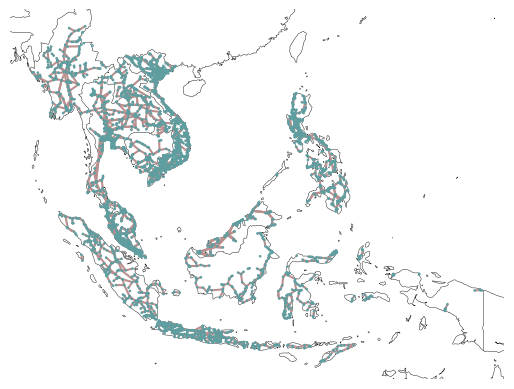

In [1]:
import pypsa

n=pypsa.Network("networks/base.nc")
n.plot()

In [2]:
import pypsa

n = pypsa.Network("networks/base.nc")

# check links first (your crash was during duplicate_links)
bad_links = n.links[(n.links.bus0 == "bus0") | (n.links.bus1 == "bus0") | (n.links.bus0 == "bus1") | (n.links.bus1 == "bus1")]
print("bad_links:", len(bad_links))
print(bad_links[["bus0","bus1"]].head(20))

# also check lines
bad_lines = n.lines[(n.lines.bus0 == "bus0") | (n.lines.bus1 == "bus0") | (n.lines.bus0 == "bus1") | (n.lines.bus1 == "bus1")]
print("bad_lines:", len(bad_lines))
print(bad_lines[["bus0","bus1"]].head(20))


Index(['transf_1_0', 'transf_2_0', 'transf_4_0', 'transf_5_0', 'transf_6_0',
       'transf_9_0', 'transf_10_0', 'transf_15_0', 'transf_17_0',
       'transf_20_0',
       ...
       'transf_2694_0', 'transf_2727_0', 'transf_2770_0', 'transf_2882_0',
       'transf_2887_0', 'transf_2923_0', 'transf_2930_0', 'transf_2996_0',
       'transf_3023_0', 'transf_3025_0'],
      dtype='object', name='name', length=885)
Index(['transf_1_0', 'transf_2_0', 'transf_4_0', 'transf_5_0', 'transf_6_0',
       'transf_9_0', 'transf_10_0', 'transf_15_0', 'transf_17_0',
       'transf_20_0',
       ...
       'transf_2694_0', 'transf_2727_0', 'transf_2770_0', 'transf_2882_0',
       'transf_2887_0', 'transf_2923_0', 'transf_2930_0', 'transf_2996_0',
       'transf_3023_0', 'transf_3025_0'],
      dtype='object', name='name', length=885)
Index(['transf_1_0', 'transf_2_0', 'transf_4_0', 'transf_5_0', 'transf_6_0',
       'transf_9_0', 'transf_10_0', 'transf_15_0', 'transf_17_0',
       'transf_20_0',
     

bad_links: 0
Empty DataFrame
Columns: [bus0, bus1]
Index: []
bad_lines: 0
Empty DataFrame
Columns: [bus0, bus1]
Index: []


In [3]:
import pandas as pd
import numpy as np

# 1) check dtypes
print(n.buses[["x","y"]].dtypes)

# 2) force numeric and find bad rows
x_num = pd.to_numeric(n.buses["x"], errors="coerce")
y_num = pd.to_numeric(n.buses["y"], errors="coerce")

bad = n.buses[x_num.isna() | y_num.isna()][["x","y","country","carrier"]]
print("bad bus coords rows:", len(bad))
print(bad.head(50))

# 3) show any *stringy* x/y values (helps if NaNs are not present but dtype is object)
mask_str = n.buses["x"].map(lambda v: isinstance(v, str)) | n.buses["y"].map(lambda v: isinstance(v, str))
print("string x/y rows:", int(mask_str.sum()))
print(n.buses.loc[mask_str, ["x","y"]].head(50))


x    float64
y    float64
dtype: object
bad bus coords rows: 0
Empty DataFrame
Columns: [x, y, country, carrier]
Index: []
string x/y rows: 0
Empty DataFrame
Columns: [x, y]
Index: []


In [1]:
import pypsa
import pandas as pd

fn = "results/prenetworks-brownfield/elec_s_79_lcopt_Co2L-3h_3h_2030_0.05_ASEAN_0export.nc"
n = pypsa.Network(fn)

def missing_bus_rows(df, cols):
    m = pd.Series(False, index=df.index)
    for c in cols:
        if c in df.columns:
            m |= ~df[c].isin(n.buses.index)
    return df.loc[m, cols + [c for c in ["carrier"] if c in df.columns]]

print("buses:", len(n.buses))

# 1) missing-bus components (these are the ones that break topology)
checks = {
    "generators": (n.generators, ["bus"]),
    "loads": (n.loads, ["bus"]),
    "stores": (n.stores, ["bus"]),
    "storage_units": (n.storage_units, ["bus"]),
    "lines": (n.lines, ["bus0","bus1"]),
    "links": (n.links, ["bus0","bus1","bus2","bus3","bus4"]),
}
for name,(df,cols) in checks.items():
    bad = missing_bus_rows(df, cols)
    if len(bad):
        print(f"\n{name}: {len(bad)} rows reference missing buses")
        print(bad.head(20))

# 2) islands with load but no supply capacity (quick heuristic)
# build sub_networks first
n.determine_network_topology()

# aggregate per sub_network
bus_sn = n.buses.sub_network
load_by_sn = n.loads.groupby(bus_sn.loc[n.loads.bus].values).p_set.sum(min_count=1)

# supply proxies: extendable+fixed generator p_nom, storage power, imports through links are harder,
# but this already catches the classic "dangling LV/heat bus" case
gen_cap_by_sn = n.generators.groupby(bus_sn.loc[n.generators.bus].values).p_nom.sum(min_count=1)

df_sn = pd.DataFrame({
    "load_p_set_sum": load_by_sn,
    "gen_p_nom_sum": gen_cap_by_sn
}).fillna(0).sort_values("load_p_set_sum", ascending=False)

print("\nsub_network summary (top 30 by load):")
print(df_sn.head(30))

print("\nsub_networks with load but ~zero generator capacity:")
print(df_sn[(df_sn.load_p_set_sum>0) & (df_sn.gen_p_nom_sum<1e-6)].head(50))


Index(['ID7 0 solar rooftop-2030', 'MY32 0 solar rooftop-2030'], dtype='object', name='name')
Index(['BN21 0 urban central solid biomass CHP CC-2030',
       'ID10 0 urban central solid biomass CHP CC-2030',
       'ID10 1 urban central solid biomass CHP CC-2030',
       'ID11 0 urban central solid biomass CHP CC-2030',
       'ID11 1 urban central solid biomass CHP CC-2030',
       'ID12 0 urban central solid biomass CHP CC-2030',
       'ID12 1 urban central solid biomass CHP CC-2030',
       'ID13 0 urban central solid biomass CHP CC-2030',
       'ID13 1 urban central solid biomass CHP CC-2030',
       'ID14 0 urban central solid biomass CHP CC-2030',
       'ID14 1 urban central solid biomass CHP CC-2030',
       'ID15 0 urban central solid biomass CHP CC-2030',
       'ID15 1 urban central solid biomass CHP CC-2030',
       'ID16 0 urban central solid biomass CHP CC-2030',
       'ID16 1 urban central solid biomass CHP CC-2030',
       'ID25 0 urban central solid biomass CHP CC-2

buses: 1734

generators: 2 rows reference missing buses
                                          bus        carrier
Generator                                                   
ID7 0 solar rooftop-2030    ID7 0 low voltage  solar rooftop
MY32 0 solar rooftop-2030  MY32 0 low voltage  solar rooftop

links: 3747 rows reference missing buses
                               bus0            bus1            bus2 bus3 bus4  \
Link                                                                            
convert_241_436              MY32 0          MY22 0                             
convert_795_1258              ID7 0           ID5 1                             
convert_1892_2695            TH24 0           TH1 2                             
convert_2505_3357            ID30 0           ID5 0                             
Plentong - Woodlands         MY22 0          SG33 0                             
Peninsular MY – Sarawak      MY22 0          MY21 1                             
Telok Gong

KeyError: "['ID7 0 low voltage', 'MY32 0 low voltage'] not in index"

In [2]:
for g in ["ID7 0 solar", "MY32 0 solar"]:
    b = n.generators.at[g, "bus"]
    print("\n", g)
    print("  base bus:", b)
    print("  base bus exists:", b in n.buses.index)
    print("  base bus carrier:", n.buses.at[b, "carrier"] if b in n.buses.index else None)
    print("  lv bus:", b + " low voltage")
    print("  lv bus exists:", (b + " low voltage") in n.buses.index)


KeyError: 'ID7 0 solar'

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pypsa

def plot_network_base_vs_extended_on_asean_background(
    n_base,
    n_ext,
    year_tag=None,
    *,
    asean=("BN","KH","ID","LA","MY","MM","PH","SG","TH","VN"),
    include_lines=True,
    include_links=True,
    only_ac_lines=False,     # if True: keep only AC lines (if carrier exists)
    cap_min_gw=0.0,          # raise to declutter
    cap_max_gw=None,
    aggregate_parallel=False,  # keep False for meshed view
    # widths
    linewidth_min=1.5,
    linewidth_max=2.6,
    width_quantile=0.995,
    alpha_base=0.55,
    alpha_new=0.95,
    # colors
    base_color="#0B56FA",    # dark
    new_color="#94210d",     # teal
    # map styling
    figsize=(13.5, 9.5),
    dpi=240,
    extent=None,
    ocean_color="#fbfbfb",
    bg_color="#ffffff",
    coast_color="#374151",
    border_color="#6b7280",
    admin1_color="#cfd4dc",
    coast_lw=1.05,
    border_lw=0.95,
    admin1_lw=0.45,
    show_admin1=True,
    land_alpha=1.0,
    show_country_labels=True,
    country_label_size=12,
    show_nodes=False,
    node_size=6,
    node_alpha=0.18,
    # legend widths
    ref_gw=(0.05, 0.1, 0.5, 1, 5, 10),
    savepath=None,
    show=True,
    return_df=True,
):
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    import cartopy.io.shapereader as shpreader
    from matplotlib.lines import Line2D
    from pathlib import Path

    asean = tuple(asean)
    asean_set = set(asean)

    # ---------- helpers ----------
    def _xy(n):
        b = n.buses
        if "lon" in b.columns and "lat" in b.columns:
            return b["lon"].astype(float), b["lat"].astype(float)
        if "x" in b.columns and "y" in b.columns:
            return b["x"].astype(float), b["y"].astype(float)
        raise KeyError("buses need lon/lat or x/y")

    def _cc_from_busname(bus):
        return str(bus).strip()[:2].upper()

    def bus_to_countrycode(n, bus):
        b = str(bus)
        if "country" in n.buses.columns and b in n.buses.index:
            v = n.buses.at[b, "country"]
            if pd.notna(v):
                return str(v).upper()
        return _cc_from_busname(b)

    def _cap_opt(df, col):
        if df is None or df.empty:
            return pd.Series(dtype=float)
        if col not in df.columns:
            # allow plotting non-optimized base networks
            if col.replace("_opt", "") in df.columns:
                return df[col.replace("_opt", "")].fillna(0.0).astype(float)
            raise KeyError(f"missing required '{col}' (or '{col.replace('_opt','')}')")
        return df[col].fillna(0.0).astype(float)

    def _assets_df(n):
        rows = []

        if include_lines and getattr(n, "lines", None) is not None and len(n.lines):
            # capacity: s_nom_opt else s_nom
            s_nom = _cap_opt(n.lines, "s_nom_opt")
            dfL = n.lines[["bus0", "bus1"]].copy()
            dfL["type"] = "line"
            dfL["id"] = dfL.index.astype(str)
            dfL["cap_gw"] = (s_nom.loc[dfL.index].astype(float) / 1e3).values
            dfL["carrier"] = n.lines["carrier"].astype(str).reindex(dfL.index).values if "carrier" in n.lines.columns else "line"
            rows.append(dfL.reset_index(drop=True))

        if include_links and getattr(n, "links", None) is not None and len(n.links):
            p_nom = _cap_opt(n.links, "p_nom_opt")
            dfK = n.links[["bus0", "bus1"]].copy()
            dfK["type"] = "link"
            dfK["id"] = dfK.index.astype(str)
            dfK["cap_gw"] = (p_nom.loc[dfK.index].astype(float) / 1e3).values
            dfK["carrier"] = n.links["carrier"].astype(str).reindex(dfK.index).values if "carrier" in n.links.columns else "link"
            rows.append(dfK.reset_index(drop=True))

        if not rows:
            raise ValueError("no lines/links found in network")

        df = pd.concat(rows, ignore_index=True)
        df["bus0"] = df["bus0"].astype(str)
        df["bus1"] = df["bus1"].astype(str)

        if only_ac_lines and "carrier" in df.columns:
            # keep AC lines (and allow links to pass if you want)
            df = df[(df["type"] != "line") | (df["carrier"].str.contains(r"\bAC\b", case=False, na=False))].copy()

        # filter ASEAN-to-ASEAN
        df["c0"] = df["bus0"].map(lambda b: bus_to_countrycode(n, b))
        df["c1"] = df["bus1"].map(lambda b: bus_to_countrycode(n, b))
        df = df[df["c0"].isin(asean_set) & df["c1"].isin(asean_set)].copy()

        # stable undirected edge key + keep type
        u = np.minimum(df["bus0"].values, df["bus1"].values)
        v = np.maximum(df["bus0"].values, df["bus1"].values)
        df["edge_key"] = df["type"].astype(str) + "::" + pd.Series(u).astype(str) + "||" + pd.Series(v).astype(str)

        return df

    df_base = _assets_df(n_base)
    df_ext  = _assets_df(n_ext)

    # optionally aggregate parallels (within each network)
    def _aggregate(df):
        if not aggregate_parallel:
            return df.copy()
        g = df.groupby(["edge_key", "type", "bus0", "bus1"], as_index=False).agg(cap_gw=("cap_gw", "sum"))
        return g

    df_base2 = _aggregate(df_base)
    df_ext2  = _aggregate(df_ext)

    base_keys = set(df_base2["edge_key"].astype(str).tolist())
    df_ext2["is_new"] = ~df_ext2["edge_key"].astype(str).isin(base_keys)

    # capacity filter
    if cap_min_gw is not None:
        df_ext2 = df_ext2[df_ext2["cap_gw"].astype(float) >= float(cap_min_gw)].copy()
    if cap_max_gw is not None:
        df_ext2 = df_ext2[df_ext2["cap_gw"].astype(float) <= float(cap_max_gw)].copy()
    if df_ext2.empty:
        raise ValueError("after capacity filtering, nothing remains")

    # width scaling (shared)
    cap = df_ext2["cap_gw"].astype(float).fillna(0.0).values
    cap_pos = cap[cap > 0]
    cap_ref = float(np.nanquantile(cap_pos, width_quantile)) if cap_pos.size else 1.0
    cap_ref = max(cap_ref, 1e-6)

    def _w(cap_gw):
        x = np.clip(cap_gw, 0, cap_ref)
        return linewidth_min + (linewidth_max - linewidth_min) * (np.log1p(x) / np.log1p(cap_ref))

    widths = np.array([_w(c) for c in cap], dtype=float)

    # extent (use extended buses)
    lonb, latb = _xy(n_ext)
    if extent is None:
        ok = lonb.between(90, 145) & latb.between(-15, 30)
        if ok.any():
            lo, la = lonb[ok], latb[ok]
            pad_lon = max(1.0, (lo.max() - lo.min()) * 0.08)
            pad_lat = max(1.0, (la.max() - la.min()) * 0.08)
            extent = [float(lo.min() - pad_lon), float(lo.max() + pad_lon),
                      float(la.min() - pad_lat), float(la.max() + pad_lat)]
        else:
            extent = [92, 141, -12, 25]

    # bus coordinate lookup (extended)
    buses = n_ext.buses.copy()
    lon_s, lat_s = _xy(n_ext)
    lon_by = pd.Series(lon_s.values, index=buses.index.astype(str), dtype=float)
    lat_by = pd.Series(lat_s.values, index=buses.index.astype(str), dtype=float)

    # ---------- plot basemap ----------
    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(1, 1, 1, projection=proj)
    ax.set_extent(extent, crs=proj)
    ax.set_facecolor(bg_color)

    ax.add_feature(cfeature.OCEAN.with_scale("50m"), facecolor=ocean_color, alpha=1.0, zorder=0)

    country_facecolors = {
        "BN": "#d9d9d9", "KH": "#efefef", "ID": "#e3e3e3", "LA": "#f2f2f2",
        "MY": "#d0d0d0", "MM": "#e8e8e8", "PH": "#cccccc", "SG": "#bfbfbf",
        "TH": "#f5f5f5", "VN": "#dadada",
    }
    shp = shpreader.natural_earth(resolution="50m", category="cultural", name="admin_0_countries")
    for rec in shpreader.Reader(shp).records():
        iso2 = rec.attributes.get("ISO_A2")
        if iso2 not in asean_set:
            continue
        geom = rec.geometry
        ax.add_geometries([geom], crs=proj,
                          facecolor=country_facecolors.get(iso2, "#e5e5e5"),
                          edgecolor="none", alpha=land_alpha, zorder=0.4)
        if show_country_labels:
            rp = geom.representative_point()
            ax.text(rp.x, rp.y, iso2, transform=proj,
                    ha="center", va="center",
                    fontsize=country_label_size, fontweight="bold", color="#111827",
                    bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.7),
                    zorder=6)

    if show_admin1:
        ax.add_feature(cfeature.STATES.with_scale("50m"),
                       edgecolor=admin1_color, facecolor="none",
                       linewidth=admin1_lw, alpha=0.65, zorder=1.2)

    ax.add_feature(cfeature.BORDERS.with_scale("50m"),
                   edgecolor=border_color, linewidth=border_lw, alpha=0.9, zorder=2)
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"),
                   edgecolor=coast_color, linewidth=coast_lw, alpha=0.95, zorder=3)

    if show_nodes:
        bus_cc = buses.index.astype(str).map(lambda b: bus_to_countrycode(n_ext, b))
        mask = bus_cc.isin(asean_set)
        ax.scatter(lon_s[mask].values, lat_s[mask].values,
                   transform=proj, s=node_size, alpha=node_alpha, zorder=4)

    # ---------- draw edges: base first (grey), new on top (teal) ----------
    dfp = df_ext2.reset_index(drop=True)
    for i, r in dfp.iterrows():
        b0, b1 = str(r["bus0"]), str(r["bus1"])
        if (b0 not in lon_by.index) or (b1 not in lon_by.index):
            continue

        x0, y0 = float(lon_by.at[b0]), float(lat_by.at[b0])
        x1, y1 = float(lon_by.at[b1]), float(lat_by.at[b1])

        is_new = bool(r["is_new"])
        col = new_color if is_new else base_color
        a   = alpha_new if is_new else alpha_base

        ax.plot([x0, x1], [y0, y1], transform=proj,
                color=col, linewidth=float(widths[i]), alpha=a,
                solid_capstyle="round", zorder=5 if not is_new else 6)

    # ---------- legends ----------
    # color legend
    color_handles = [
        Line2D([0],[0], color=base_color, lw=2.4, alpha=alpha_base, solid_capstyle="round", label="Existing network"),
        Line2D([0],[0], color=new_color,  lw=2.8, alpha=alpha_new,  solid_capstyle="round", label="APG"),
    ]

    # width legend
    ref_gw = np.array(list(ref_gw), dtype=float)
    ref_w  = np.array([_w(g) for g in ref_gw], dtype=float)
    width_handles = [Line2D([0], [0], color="#0A1013", lw=w, solid_capstyle="round") for w in ref_w]
    width_labels  = [f"{g:g} gw" for g in ref_gw]

    leg1 = ax.legend(handles=color_handles, loc="lower left",
                     frameon=True, framealpha=0.92, title="Edges")
    ax.add_artist(leg1)
    ax.legend(handles=width_handles, labels=width_labels,
              loc="lower left", bbox_to_anchor=(0.0, 0.16),
              frameon=True, framealpha=0.92, title="Capacity (width)")

    # title
    tag = f" ({year_tag})" if year_tag is not None else ""
    ax.set_title(f"ASEAN APG Interconnections",
                 loc="left", fontsize=15, fontweight="bold", pad=10)

    if savepath is None:
        savepath = f"results/network_maps/asean_network_base_vs_extended{('_'+str(year_tag)) if year_tag is not None else ''}.png"
    Path(savepath).parent.mkdir(parents=True, exist_ok=True)

    if show:
        plt.show()
    else:
        fig.canvas.draw()
        fig.savefig(savepath, dpi=dpi, bbox_inches="tight")
        plt.close(fig)

    return df_ext2 if return_df else None


# --- example ---
n_ext  = pypsa.Network("prenetworks/elec_s_79_lcopt_Co2L-6h_6h_2030_0.05_ASEAN_0export.nc")
df = plot_network_base_vs_extended_on_asean_background(
     n_base, n_ext, year_tag=2045,
     cap_min_gw=0,
     aggregate_parallel=False,
     show=True,
 )


KeyboardInterrupt: 

In [ ]:
import pypsa
n_ext  = pypsa.Network("results/prenetworks/elec_s_79_lcopt_Co2L-6h_6h_2030_0.05_ASEAN_0export.nc")

n_ext.plot()

FileNotFoundError: [Errno 2] No such file or directory: '/scratch/htc/ffakhira/pypsa-earth-local/prenetworks/elec_s_79_lcopt_Co2L-6h_6h_2030_0.05_ASEAN_0export.nc'